# 02 — Baseline Classifiers

This notebook trains four baseline classifiers on two binary cognitive-load tasks:
- **Task 1 — Rest vs Load**: can we detect *any* cognitive load?
- **Task 2 — WM vs VA**: can we tell *which type* of load (Working Memory vs Visual Attention)?

Models: **SVM, Random Forest, KNN, XGBoost**  
Split: **80/20 time-based** (no shuffling — preserves temporal order within each participant)  
Target to match: **SVM ~62% accuracy on WM vs VA** (Jin et al., 2025)

## 1. Imports and Setup

In [ ]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import optuna
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import KFold
from sklearn.base import clone
import sys
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
import scripts.feature_importance as fi

sns.set_theme(style='whitegrid')
RESULTS = Path('../results/baselines')
RESULTS.mkdir(exist_ok=True)

print('All imports OK.')

c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK.


## 2. Load Data and Define Features

We use only the 7 **index features** — the hand-crafted eye-tracking statistics computed per window.
Metadata columns (`participant`, `window_index`, etc.) and derived label columns are excluded from the feature matrix.

| Feature | Description |
|---|---|
| `ipas` | Index of Pupillary Activity — short-term pupil fluctuation |
| `lhipas` | Low/High Index of Pupillary Activity — ratio of slow to fast pupil changes |
| `fixation_nums` | Number of fixations in the window |
| `fixation_durations` | Mean fixation duration in the window |
| `blink_rate` | Number of blinks in the window |
| `saccade_speeds` | Mean saccade velocity in the window |
| `saccade_peak_speeds` | Peak saccade velocity in the window |

In [2]:
with open('../data/features/features_512_511.pkl', 'rb') as f:
    df = pickle.load(f)

FEATURES = [
    'ipas', 'lhipas', 'fixation_nums', 'fixation_durations',
    'blink_rate', 'saccade_speeds', 'saccade_peak_speeds'
]

print('Dataset shape:', df.shape)
print('Features used:', FEATURES)
print('\nMissing values in feature columns:')
print(df[FEATURES].isnull().sum())

Dataset shape: (347196, 18)
Features used: ['ipas', 'lhipas', 'fixation_nums', 'fixation_durations', 'blink_rate', 'saccade_speeds', 'saccade_peak_speeds']

Missing values in feature columns:
ipas                   0
lhipas                 0
fixation_nums          0
fixation_durations     0
blink_rate             0
saccade_speeds         0
saccade_peak_speeds    0
dtype: int64


## 3. Time-Based 80/20 Train/Test Split

We sort by `participant` then `window_index` to preserve the temporal order of recordings.
The first 80% of rows become the training set and the last 20% become the test set.

**Why no shuffling?**  
Eye-tracking signals are time series. Shuffling would leak future information into the training set
(the model could see windows recorded *after* the test windows). A time-based split simulates a
realistic deployment scenario where the model is trained on earlier sessions and evaluated on later ones.

In [3]:
df_sorted = df.sort_values(['participant', 'window_index']).reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.8)
train_df = df_sorted.iloc[:split_idx]
test_df  = df_sorted.iloc[split_idx:]

print(f'Total windows : {len(df_sorted):,}')
print(f'Train windows : {len(train_df):,}  ({len(train_df)/len(df_sorted)*100:.1f}%)')
print(f'Test  windows : {len(test_df):,}  ({len(test_df)/len(df_sorted)*100:.1f}%)')

Total windows : 347,196
Train windows : 277,756  (80.0%)
Test  windows : 69,440  (20.0%)


## 4. Prepare Task Datasets

We remap the original 7-class `label` column into two separate binary targets:

- **Task 1 — Rest vs Load**: `0 → Rest (0)`, `1–6 → Load (1)`
- **Task 2 — WM vs VA**: `1–3 → WM (0)`, `4–6 → VA (1)`, rest excluded entirely

For each task we also fit a `StandardScaler` on the training features and apply it to the test set.
Scaling is necessary for SVM and KNN (distance-based / margin-based methods that are sensitive to feature scale).
Random Forest and XGBoost are tree-based and scale-invariant, but we scale all models for consistency.

In [4]:
def make_task(train, test, task):
    """Return (X_train, y_train, X_test, y_test) for a given task."""
    if task == 'rest_vs_load':
        tr = train.copy()
        te = test.copy()
        y_tr = (tr['label'] != 0).astype(int)
        y_te = (te['label'] != 0).astype(int)
    elif task == 'wm_vs_va':
        tr = train[train['label'] != 0].copy()
        te = test[test['label'] != 0].copy()
        y_tr = (tr['label'] > 3).astype(int)   # 0=WM, 1=VA
        y_te = (te['label'] > 3).astype(int)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr[FEATURES])
    X_te = scaler.transform(te[FEATURES])
    return X_tr, y_tr.values, X_te, y_te.values

X_tr1, y_tr1, X_te1, y_te1 = make_task(train_df, test_df, 'rest_vs_load')
X_tr2, y_tr2, X_te2, y_te2 = make_task(train_df, test_df, 'wm_vs_va')

print('Task 1 — Rest vs Load')
print(f'  Train: {X_tr1.shape}, class balance: {np.bincount(y_tr1)}')
print(f'  Test : {X_te1.shape}, class balance: {np.bincount(y_te1)}')
print()
print('Task 2 — WM vs VA (rest excluded)')
print(f'  Train: {X_tr2.shape}, class balance: {np.bincount(y_tr2)}')
print(f'  Test : {X_te2.shape}, class balance: {np.bincount(y_te2)}')

Task 1 — Rest vs Load
  Train: (277756, 7), class balance: [ 17240 260516]
  Test : (69440, 7), class balance: [ 5279 64161]

Task 2 — WM vs VA (rest excluded)
  Train: (260516, 7), class balance: [131412 129104]
  Test : (64161, 7), class balance: [30943 33218]


## 5. Define Models and Evaluation Helpers

Four models are used as baselines. Each is a well-established classical classifier:

| Model | Key hyperparameters | Notes |
|---|---|---|
| **SVM** | `LinearSVC`, C=1.0 | Linear kernel chosen for speed on ~280k samples; matches typical EEG/eye-tracking baselines |
| **Random Forest** | 200 trees, `n_jobs=-1` | Ensemble of decision trees; robust to outliers and scale |
| **KNN** | k=11, `n_jobs=-1` | Majority vote of 11 nearest neighbours in feature space |
| **XGBoost** | 200 trees, `n_jobs=-1` | Gradient-boosted trees; often the strongest classical baseline |

Metrics reported: **accuracy, precision, recall, F1** (all with `average='binary'` for the binary tasks).

In [5]:
def get_models():
    return {
        'Logistic Regression': LogisticRegression(max_iter=5000, class_weight='balanced', n_jobs=-1, random_state=42),
        'SVM':           LinearSVC(C=1.0, max_iter=3000, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
        'KNN':           KNeighborsClassifier(n_neighbors=11, n_jobs=-1),
        'XGBoost':       XGBClassifier(n_estimators=200, n_jobs=-1, eval_metric='logloss',
                                       random_state=42, verbosity=0),
    }

def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'accuracy':  round(accuracy_score(y_te, y_pred), 4),
        'precision': round(precision_score(y_te, y_pred, average='binary', zero_division=0), 4),
        'recall':    round(recall_score(y_te, y_pred, average='binary', zero_division=0), 4),
        'f1':        round(f1_score(y_te, y_pred, average='binary', zero_division=0), 4),
        'y_pred':    y_pred,
    }

print('Model definitions ready.')

Model definitions ready.


## 6. Task 1 — Rest vs Load

Binary classification: **Rest (0)** vs **Load (1)**.  
This is the easier of the two tasks — we just need to detect whether any cognitive effort is present.

In [6]:
print('Training Task 1 — Rest vs Load ...')
results_t1 = {}
for name, model in get_models().items():
    print(f'  {name} ...', end=' ', flush=True)
    results_t1[name] = evaluate(model, X_tr1, y_tr1, X_te1, y_te1)
    print(f"acc={results_t1[name]['accuracy']:.4f}")

# metrics table
rows = []
for name, r in results_t1.items():
    rows.append({'Model': name, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
                 'Recall': r['recall'], 'F1': r['f1']})
df_t1 = pd.DataFrame(rows).set_index('Model')
print('\nTask 1 Results:')
df_t1

Training Task 1 — Rest vs Load ...
  Logistic Regression ... 

c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


acc=0.9952
  SVM ... acc=0.9944
  Random Forest ... acc=0.9810
  KNN ... acc=0.9800
  XGBoost ... acc=0.9759

Task 1 Results:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.9952,0.9977,0.9971,0.9974
SVM,0.9944,0.9945,0.9994,0.9970
Random Forest,0.9810,0.9869,0.9926,0.9898
KNN,0.9800,0.9817,0.9969,0.9893
XGBoost,0.9759,0.9791,0.9952,0.9871


### Confusion Matrices — Task 1

Each cell shows the number of test windows classified into that category.
- **Top-left / bottom-right**: correct predictions (true negatives / true positives)
- **Top-right**: false positives (rest windows classified as load)
- **Bottom-left**: false negatives (load windows classified as rest)

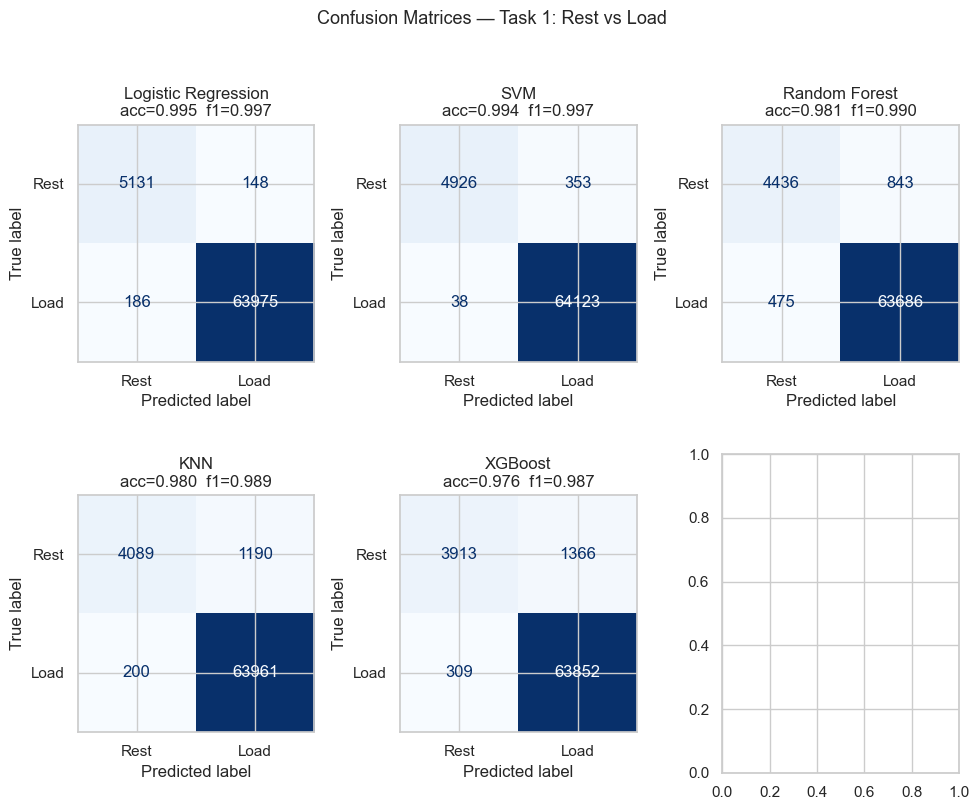

Saved: results/baselines/confusion_matrix_rest_vs_load.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
class_names_t1 = ['Rest', 'Load']

for ax, (name, r) in zip(axes.flatten(), results_t1.items()):
    cm = confusion_matrix(y_te1, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names_t1)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nacc={r['accuracy']:.3f}  f1={r['f1']:.3f}")

plt.suptitle('Confusion Matrices — Task 1: Rest vs Load', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'confusion_matrix_rest_vs_load.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/baselines/confusion_matrix_rest_vs_load.png')

## 7. Task 2 — WM vs VA

Binary classification: **WM (0)** vs **VA (1)**, with rest windows excluded.  
This is the harder task — the signal differences between WM and VA tasks are subtler.  
**Target from Jin et al. (2025): SVM ~62% accuracy.**

In [8]:
print('Training Task 2 — WM vs VA ...')
results_t2 = {}
trained_models_t2 = {}
for name, model in get_models().items():
    print(f'  {name} ...', end=' ', flush=True)
    results_t2[name] = evaluate(model, X_tr2, y_tr2, X_te2, y_te2)
    trained_models_t2[name] = model
    print(f"acc={results_t2[name]['accuracy']:.4f}")

rows = []
for name, r in results_t2.items():
    rows.append({'Model': name, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
                 'Recall': r['recall'], 'F1': r['f1']})
df_t2 = pd.DataFrame(rows).set_index('Model')
print('\nTask 2 Results:')
df_t2

Training Task 2 — WM vs VA ...
  Logistic Regression ... 

c:\Users\HP\Documents\Uni_Stuttgart\CAI\caip2\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


acc=0.8666
  SVM ... acc=0.8567
  Random Forest ... acc=0.8676
  KNN ... acc=0.8011
  XGBoost ... acc=0.8542

Task 2 Results:


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.8666,0.7996,0.9906,0.8849
SVM,0.8567,0.7862,0.9933,0.8777
Random Forest,0.8676,0.8075,0.9772,0.8843
KNN,0.8011,0.7594,0.9016,0.8244
XGBoost,0.8542,0.7975,0.9629,0.8724


### Confusion Matrices — Task 2

Same layout as Task 1. Here the classes are WM (Working Memory) and VA (Visual Attention).
Watch for systematic confusion — e.g. if the model always predicts WM, that tells us the features
are not discriminating between the two load types well.

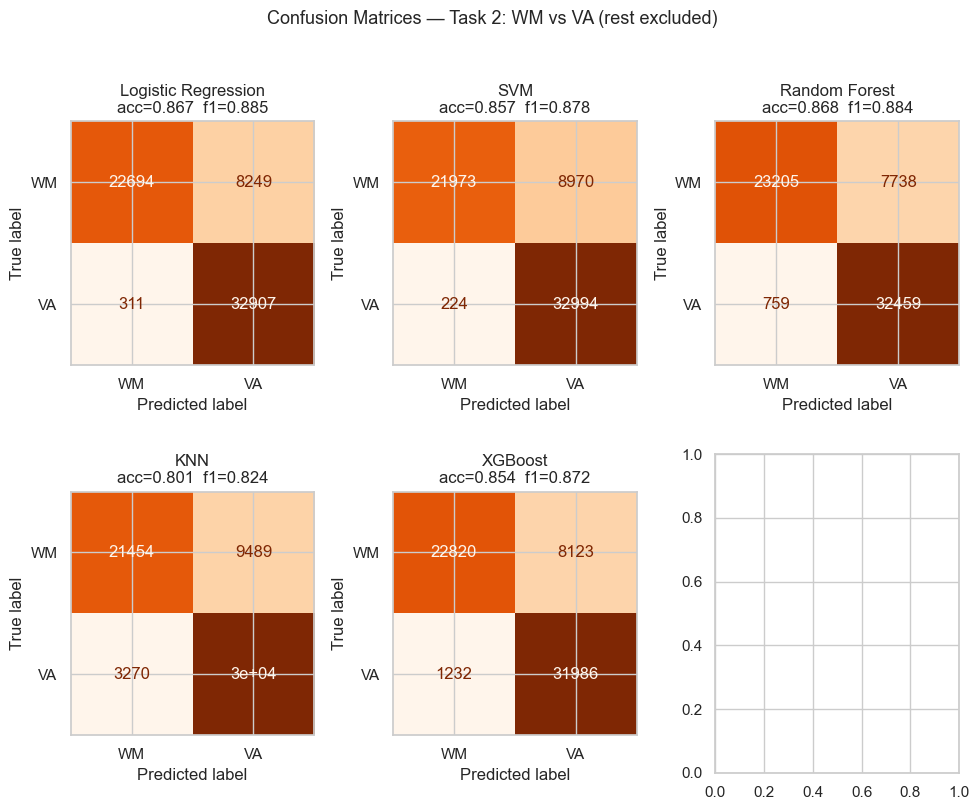

Saved: results/baselines/confusion_matrix_wm_vs_va.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(10, 8))
class_names_t2 = ['WM', 'VA']

for ax, (name, r) in zip(axes.flatten(), results_t2.items()):
    cm = confusion_matrix(y_te2, r['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names_t2)
    disp.plot(ax=ax, colorbar=False, cmap='Oranges')
    ax.set_title(f"{name}\nacc={r['accuracy']:.3f}  f1={r['f1']:.3f}")

plt.suptitle('Confusion Matrices — Task 2: WM vs VA (rest excluded)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / 'confusion_matrix_wm_vs_va.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/baselines/confusion_matrix_wm_vs_va.png')

## 8. Summary Results Table

All metrics for both tasks in one table. Saved as a CSV to `results/baselines/baseline_results.csv`.

The **SVM accuracy on Task 2 (WM vs VA)** is the primary number to compare against Jin et al. (2025) who report ~62%.

In [10]:
rows_all = []
for task_name, results in [('Rest vs Load', results_t1), ('WM vs VA', results_t2)]:
    for model_name, r in results.items():
        rows_all.append({
            'Task': task_name,
            'Model': model_name,
            'Accuracy': r['accuracy'],
            'Precision': r['precision'],
            'Recall': r['recall'],
            'F1': r['f1'],
        })

df_all = pd.DataFrame(rows_all)
df_all.to_csv(RESULTS / 'baseline_results.csv', index=False)
print('Saved: results/baselines/baseline_results.csv\n')

# Pretty-print
print(df_all.to_string(index=False))

# Highlight SVM on Task 2 vs target
svm_t2_acc = results_t2['SVM']['accuracy']
print(f'\nSVM accuracy on WM vs VA: {svm_t2_acc*100:.1f}%')
print(f'Jin et al. (2025) target:  ~62.0%')
diff = svm_t2_acc * 100 - 62.0
print(f'Difference: {diff:+.1f} percentage points')

Saved: results/baselines/baseline_results.csv

        Task               Model  Accuracy  Precision  Recall     F1
Rest vs Load Logistic Regression    0.9952     0.9977  0.9971 0.9974
Rest vs Load                 SVM    0.9944     0.9945  0.9994 0.9970
Rest vs Load       Random Forest    0.9810     0.9869  0.9926 0.9898
Rest vs Load                 KNN    0.9800     0.9817  0.9969 0.9893
Rest vs Load             XGBoost    0.9759     0.9791  0.9952 0.9871
    WM vs VA Logistic Regression    0.8666     0.7996  0.9906 0.8849
    WM vs VA                 SVM    0.8567     0.7862  0.9933 0.8777
    WM vs VA       Random Forest    0.8676     0.8075  0.9772 0.8843
    WM vs VA                 KNN    0.8011     0.7594  0.9016 0.8244
    WM vs VA             XGBoost    0.8542     0.7975  0.9629 0.8724

SVM accuracy on WM vs VA: 85.7%
Jin et al. (2025) target:  ~62.0%
Difference: +23.7 percentage points


## Summary

- **Time-based 80/20 split** applied (sorted by participant + window_index, no shuffling).
- **4 models** trained on **2 binary tasks** = 8 model–task combinations.
- Metrics saved to `results/baselines/baseline_results.csv`.
- Confusion matrices saved to `results/baselines/confusion_matrix_rest_vs_load.png` and `results/baselines/confusion_matrix_wm_vs_va.png`.
- SVM accuracy on WM vs VA compared against the Jin et al. (2025) benchmark of ~62%.

Next step: feature importance analysis and model improvement (`03_modelling.ipynb`).

# Feature Importance and Model Interpretability (VA vs WM)

* SHAP (SHapley Additive exPlanations): for tree based classifiers (Random Forest, XGBoost)
* Model Coefficients: For Linear Models (Logistic Regression & SVM)
* Permutation Feature Importance: For Distance-Based Models (KNN)

In [22]:
fi.generate_all_feature_importance(
    trained_models=trained_models_t2,
    X_test=X_te2,
    y_test=y_te2,
    feature_names=FEATURES,
    output_dir=RESULTS / "task2_feature_importance"
)

<Figure size 1200x600 with 0 Axes>

# Hyperparameter Tuning with Optuna

Here participants legitimately appear in both train and test, so there's no leakage principle to defend inside CV — but you still shouldn't use plain KFold if you want the inner validation to mimic the outer split. Strictly, the "correct" thing would be a time-based inner split (e.g. TimeSeriesSplit) rather than GroupKFold, since your outer test set is the last 20% in time, not a random subset.
In practice, most people get away with plain KFold (shuffled) here since the leakage already exists at the outer level — adding more of the same leakage in the inner loop doesn't make tuning invalid, it's just consistent with the overly-optimistic nature of this strategy.

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS = 20   # raise to 50-100 if you have time/compute budget
N_SPLITS = 4    # number of GroupKFold splits within the training participants


def grouped_cv_score(model, X, y, groups, n_splits=N_SPLITS):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in kf.split(X):
        m = clone(model)
        m.fit(X[tr_idx], y[tr_idx])
        scores.append(accuracy_score(y[va_idx], m.predict(X[va_idx])))
    return np.mean(scores)

def make_objective(model_name, X, y, groups):
    def objective(trial):
        if model_name == 'Logistic Regression':
            C = trial.suggest_float('C', 1e-3, 1e2, log=True)
            model = LogisticRegression(
                C=C, max_iter=5000, class_weight='balanced',
                n_jobs=-1, random_state=42
            )

        elif model_name == 'SVM':
            C = trial.suggest_float('C', 1e-3, 1e2, log=True)
            model = LinearSVC(C=C, max_iter=5000, random_state=42)

        elif model_name == 'Random Forest':
            n_estimators = trial.suggest_int('n_estimators', 100, 300, step=50)
            max_depth = trial.suggest_int('max_depth', 3, 15)
            min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
            min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
            max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
            model = RandomForestClassifier(
                n_estimators=n_estimators, max_depth=max_depth,
                min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf,
                max_features=max_features, n_jobs=-1, random_state=42
            )

        elif model_name == 'KNN':
            n_neighbors = trial.suggest_int('n_neighbors', 3, 31, step=2)
            weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
            p = trial.suggest_int('p', 1, 2)  # 1=Manhattan, 2=Euclidean
            model = KNeighborsClassifier(
                n_neighbors=n_neighbors, weights=weights, p=p, n_jobs=-1
            )

        elif model_name == 'XGBoost':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
                'max_depth': trial.suggest_int('max_depth', 2, 10),
                'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
                'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
                'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            }
            model = XGBClassifier(
                **params, n_jobs=-1, eval_metric='logloss',
                random_state=42, verbosity=0
            )

        return grouped_cv_score(model, X, y, groups)

    return objective


def tune_model(model_name, X, y, groups, n_trials=N_TRIALS):
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_objective(model_name, X, y, groups), n_trials=n_trials, show_progress_bar=False)
    return study.best_params, study.best_value


def build_tuned_model(model_name, params):
    if model_name == 'Logistic Regression':
        return LogisticRegression(**params, max_iter=5000, class_weight='balanced', n_jobs=1, random_state=42)
    elif model_name == 'SVM':
        return LinearSVC(**params, max_iter=5000, random_state=42)
    elif model_name == 'Random Forest':
        return RandomForestClassifier(**params, n_jobs=1, random_state=42)
    elif model_name == 'KNN':
        return KNeighborsClassifier(**params, n_jobs=1)
    elif model_name == 'XGBoost':
        return XGBClassifier(**params, n_jobs=1, eval_metric='logloss', random_state=42, verbosity=0)


print('Optuna tuning utilities ready.')

In [ ]:
# Participant groups aligned with the training arrays (needed for GroupKFold)
groups_t1 = train_df['participant'].values
groups_t2 = train_df[train_df['label'] != 0]['participant'].values

print('Groups for Task 1:', len(groups_t1), '| Groups for Task 2:', len(groups_t2))

### Task 1 — Rest vs Load — Tuned Models

In [ ]:
# print('Tuning Task 1 — Rest vs Load ...')
# tuned_results_t1 = {}
# best_params_t1 = {}

# for name in get_models().keys():
#     print(f'  Tuning {name} ...', end=' ', flush=True)
#     best_params, cv_score = tune_model(name, X_tr1, y_tr1, groups_t1)
#     best_params_t1[name] = best_params
#     final_model = build_tuned_model(name, best_params)
#     tuned_results_t1[name] = evaluate(final_model, X_tr1, y_tr1, X_te1, y_te1)
#     print(f"cv_acc={cv_score:.4f}  test_acc={tuned_results_t1[name]['accuracy']:.4f}  params={best_params}")

# rows = [{'Model': n, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
#          'Recall': r['recall'], 'F1': r['f1']} for n, r in tuned_results_t1.items()]
# df_t1_tuned = pd.DataFrame(rows).set_index('Model')
# print('\nTask 1 Tuned Results:')
# df_t1_tuned

### Task 2 — WM vs VA — Tuned Models

In [ ]:
print('Tuning Task 2 — WM vs VA ...')
tuned_results_t2 = {}
best_params_t2 = {}
tuned_models_t2 = {}

for name in get_models().keys():
    print(f'  Tuning {name} ...', end=' ', flush=True)
    best_params, cv_score = tune_model(name, X_tr2, y_tr2, groups_t2)
    best_params_t2[name] = best_params
    final_model = build_tuned_model(name, best_params)
    tuned_results_t2[name] = evaluate(final_model, X_tr2, y_tr2, X_te2, y_te2)
    tuned_models_t2[name] = final_model
    print(f"cv_acc={cv_score:.4f}  test_acc={tuned_results_t2[name]['accuracy']:.4f}  params={best_params}")

rows = [{'Model': n, 'Accuracy': r['accuracy'], 'Precision': r['precision'],
         'Recall': r['recall'], 'F1': r['f1']} for n, r in tuned_results_t2.items()]
df_t2_tuned = pd.DataFrame(rows).set_index('Model')
print('\nTask 2 Tuned Results:')
df_t2_tuned

svm_t2_tuned = tuned_results_t2['SVM']['accuracy']
print(f'\nTuned SVM accuracy on WM vs VA: {svm_t2_tuned*100:.1f}%')
print(f'Jin et al. (2025) target:        ~62.0%')

### Comparison: Default Hyperparameters vs Optuna-Tuned

In [ ]:
rows_cmp = []
for task_name, default_r, tuned_r in [
    #('Rest vs Load', results_t1, tuned_results_t1),
    ('WM vs VA', results_t2, tuned_results_t2),
]:
    for model_name in default_r:
        rows_cmp.append({
            'Task': task_name, 'Model': model_name,
            'Default Acc': default_r[model_name]['accuracy'],
            'Tuned Acc': tuned_r[model_name]['accuracy'],
            'Gain (pp)': round((tuned_r[model_name]['accuracy'] - default_r[model_name]['accuracy']) * 100, 2),
        })

df_tuning_cmp = pd.DataFrame(rows_cmp)
print(df_tuning_cmp.to_string(index=False))

df_tuning_cmp.to_csv(RESULTS / 'optuna_tuning_comparison.csv', index=False)

import json
with open(RESULTS / 'best_hyperparameters.json', 'w') as f:
    json.dump({ 'task2': best_params_t2}, f, indent=2)

print('\nSaved: results/baselines/optuna_tuning_comparison.csv')
print('Saved: results/baselines/best_hyperparameters.json')